<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/feb13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *
from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
import copy as cp


In [ ]:
data = {
    "emin": [0.0, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0],
    "emax": [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0],
    "nus": [4.6503, 3.2331, 3.8892, 5.0728, 7.6006, 10.9855, 13.7082, 14.6780, 13.1287, 10.0955, 7.0781, 4.8025, 3.1851, 2.0563, 1.3191, 0.8790, 0.6365, 0.4992, 0.4183, 0.3677, 0.3278, 0.2950, 0.2753, 1.0922, 0.8626, 0.7567, 0.7231, 0.7387, 0.7761, 0.8246, 0.8153, 0.7144, 0.5692, 0.4357, 0.3296, 0.2644, 0.2173, 0.1822],
    "fe": [0.130, 0.106, 0.101, 0.097, 0.093, 0.090, 0.089, 0.089, 0.091, 0.092, 0.094, 0.103, 0.109, 0.122, 0.140, 0.146, 0.150, 0.150, 0.152, 0.150, 0.140, 0.132, 0.139, 0.130, 0.114, 0.101, 0.090, 0.089, 0.083, 0.080, 0.083, 0.089, 0.101, 0.104, 0.104, 0.105, 0.110, 0.123]
}

df = pd.DataFrame(data)

df["E_center"] = (df["emin"] + df["emax"]) / 2

print(df.head())


   emin  emax     nus     fe  E_center
0   0.0   0.6  4.6503  0.130       0.3
1   0.6   0.8  3.2331  0.106       0.7
2   0.8   1.0  3.8892  0.101       0.9
3   1.0   1.2  5.0728  0.097       1.1
4   1.2   1.4  7.6006  0.093       1.3


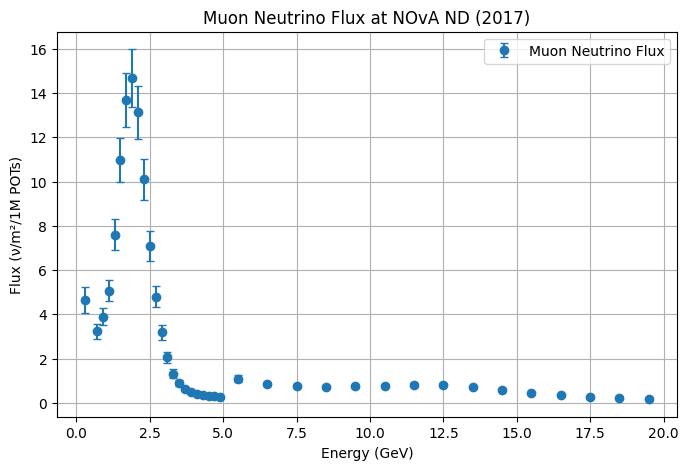

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(df["E_center"], df["nus"], yerr=df["fe"] * df["nus"], fmt='o', capsize=3, label="Muon Neutrino Flux")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (ν/m²/1M POTs)")
plt.title("Muon Neutrino Flux at NOvA ND (2017)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def oscillation_probability(E, theta, dm2, L):
    """Calculate P(νμ → νx) for a given energy."""
    sin2_2theta = np.sin(2 * theta) ** 2
    delta = 1.27 * dm2 * L / E
    return sin2_2theta * np.sin(delta) ** 2


theta = np.radians(10)
dm2 = 1.0  # eV^2
L = 810  # km (Near to Far Detector distance)

df["P_osc"] = df["E_center"].apply(lambda E: oscillation_probability(E, theta, dm2, L))
df["nus_oscillated"] = df["nus"] * (1 - df["P_osc"])  # Remaining νμ after oscillation

print(df[["E_center", "nus", "P_osc", "nus_oscillated"]].head())


   E_center     nus     P_osc  nus_oscillated
0       0.3  4.6503  0.116704        4.107591
1       0.7  3.2331  0.047849        3.078399
2       0.9  3.8892  0.030893        3.769050
3       1.1  5.0728  0.084181        4.645764
4       1.3  7.6006  0.015586        7.482135


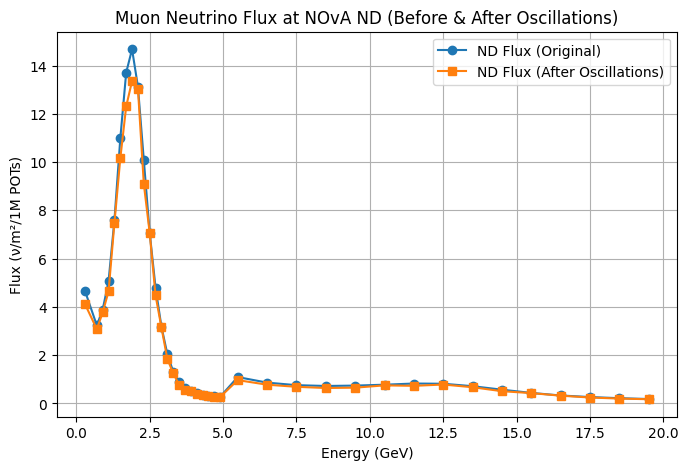

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["E_center"], df["nus"], label="ND Flux (Original)", marker='o')
plt.plot(df["E_center"], df["nus_oscillated"], label="ND Flux (After Oscillations)", marker='s')
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (ν/m²/1M POTs)")
plt.title("Muon Neutrino Flux at NOvA ND (Before & After Oscillations)")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 5.35 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


In [7]:
E_n = 1  # GeV
N_e = 1e3   # cm^-3
G_F = 1.1663787e-5  # GeV^-2

m1_squared = 0.0001
m2_squared = 0.0003
m3_squared = 0.0025
m4_squared = 0.01

U = np.eye(4)

A = 2 * np.sqrt(2) * G_F * N_e * E_n

H_eff_matter = np.array([
    [m1_squared + A, 0, 0, 0],
    [0, m2_squared, 0, 0],
    [0, 0, m3_squared, 0],
    [0, 0, 0, m4_squared + A]
])

eigenvalues_matter = np.linalg.eigvals(H_eff_matter)

delta_m21_vacuum = m2_squared - m1_squared
delta_m31_vacuum = m3_squared - m1_squared
delta_m41_vacuum = m4_squared - m1_squared

delta_m21_matter = eigenvalues_matter[1] - eigenvalues_matter[0]
delta_m31_matter = eigenvalues_matter[2] - eigenvalues_matter[0]
delta_m41_matter = eigenvalues_matter[3] - eigenvalues_matter[0]

perc_change_m21 = abs((delta_m21_vacuum - delta_m21_matter) / delta_m21_vacuum) * 100
perc_change_m31 = abs((delta_m31_vacuum - delta_m31_matter) / delta_m31_vacuum) * 100
perc_change_m41 = abs((delta_m41_vacuum - delta_m41_matter) / delta_m41_vacuum) * 100

print(f"Mass squared difference (vacuum) Δm21: {delta_m21_vacuum:.6e} eV^2")
print(f"Mass squared difference (matter) Δm21: {delta_m21_matter:.6e} eV^2")
print(f"Percentage change in Δm21 due to matter: {perc_change_m21:.2f}%\n")

print(f"Mass squared difference (vacuum) Δm31: {delta_m31_vacuum:.6e} eV^2")
print(f"Mass squared difference (matter) Δm31: {delta_m31_matter:.6e} eV^2")
print(f"Percentage change in Δm31 due to matter: {perc_change_m31:.2f}%\n")

print(f"Mass squared difference (vacuum) Δm41: {delta_m41_vacuum:.6e} eV^2")
print(f"Mass squared difference (matter) Δm41: {delta_m41_matter:.6e} eV^2")
print(f"Percentage change in Δm41 due to matter: {perc_change_m41:.2f}%")


Mass squared difference (vacuum) Δm21: 2.000000e-04 eV^2
Mass squared difference (matter) Δm21: -3.279017e-02 eV^2
Percentage change in Δm21 due to matter: 16495.09%

Mass squared difference (vacuum) Δm31: 2.400000e-03 eV^2
Mass squared difference (matter) Δm31: -3.059017e-02 eV^2
Percentage change in Δm31 due to matter: 1374.59%

Mass squared difference (vacuum) Δm41: 9.900000e-03 eV^2
Mass squared difference (matter) Δm41: 9.900000e-03 eV^2
Percentage change in Δm41 due to matter: 0.00%


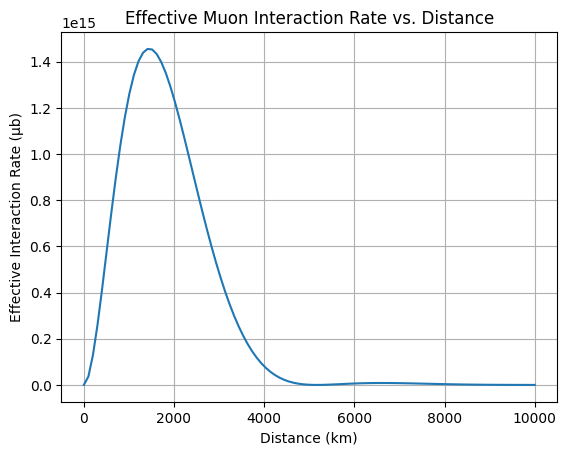

In [14]:
Delta_m32 = 2.4e-3  # eV^2
E = 5  # Fixed energy in GeV

# Oscillation probability with decaying amplitude
def P_osc_mu(L, E, L0):
    return np.sin(1.267 * Delta_m32 * L / E) ** 2 * np.exp(-L / L0)

# Effective interaction rate as a function of distance
def effective_interaction_rate(L, E, sin2theta_W=0.23, L0=1000):
    sigma = sigma_CC(E, sin2theta_W)  # Cross-section in microbarns
    return sigma * P_osc_mu(L, E, L0)  # Effective rate

# Distance range (1 km to 10,000 km)
L = np.linspace(1, 10000, 100)
rate_eff = effective_interaction_rate(L, E)

# Plotting
plt.plot(L, rate_eff)
plt.title('Effective Muon Interaction Rate vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Effective Interaction Rate (µb)')
plt.grid(True)
plt.show()